# Comparison: custom dataset vs LFW benchmark

Authors: Anthony Miranda, Lea Carminati

This notebook compares the face-recognition pipeline on two datasets, **using the exact same code path** for both:

- **LFW** (Labeled Faces in the Wild) a standard academic benchmark. It plays the role of a *reference*: it tells us whether our pipeline (MediaPipe + ArcFace + Qdrant) behaves correctly under clean, frontal, well-lit conditions.
- **Our custom dataset** built by us via webcam, deliberately including hard acquisition conditions (masks, hats, profiles, sunglasses, low light).

The goal is **not** to declare a winner: the two datasets differ in size, number of identities and difficulty, so a head-to-head score would be meaningless. The point is *methodological validation*,  LFW confirms the pipeline is sound, and the gap between the two quantifies the cost of real-world acquisition conditions.

In [9]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from eval_tools import compute_metrics, bootstrap_metric, tar_at_far, d_prime, get_condition 
from IPython.display import Markdown, display


# Same threshold grid for both datasets -> fair, identical computation
THRESHOLDS = np.linspace(0, 1, 101)
N_BOOT = 1000

with open("results_custom.pkl", "rb") as f:
    custom = pickle.load(f)
with open("results_lfw.pkl", "rb") as f:
    lfw = pickle.load(f)

datasets = {
    "Custom (real conditions)": custom,
    "LFW (benchmark)":          lfw,
}

## Compute metrics for both datasets

We run `compute_metrics` and a bootstrap (B=1000) on each dataset. Bootstrap is what makes the comparison honest: with a small dataset the point estimate alone is not trustworthy, so we report a 95% confidence interval alongside every figure.

In [10]:
results = {}
for name, d in datasets.items():
    g, imp = d["genuine"], d["impostor"]
    m  = compute_metrics(g, imp, THRESHOLDS)
    be = bootstrap_metric(g, imp, THRESHOLDS, "eer_value", n_boot=N_BOOT)
    ba = bootstrap_metric(g, imp, THRESHOLDS, "auc",       n_boot=N_BOOT)
    tf = tar_at_far(m, THRESHOLDS, 0.01)
    results[name] = {
        "n_genuine":  len(g),
        "n_impostor": len(imp),
        "metrics":    m,
        "eer_ci":     (be["ci_low"], be["ci_high"]),
        "auc_ci":     (ba["ci_low"], ba["ci_high"]),
        "dprime":     d_prime(g, imp),
        "tar_at_far": tf,
    }
    print(f"{name}: EER={m['eer_value']:.3f}  AUC={m['auc']:.3f}  d'={results[name]['dprime']:.2f}  (n_g={len(g)}, n_i={len(imp)})")

Custom (real conditions): EER=0.260  AUC=0.638  d'=0.67  (n_g=89, n_i=16)
LFW (benchmark): EER=0.056  AUC=0.979  d'=3.45  (n_g=917, n_i=298)


## Summary table

The key figures side by side, each with its 95% confidence interval.

In [11]:

names = list(results.keys())
header = "| Metric | " + " | ".join(names) + " |"
sep    = "|" + "---|" * (len(names) + 1)
rows = [header, sep]

def fmt_ci(val, ci, pct=False):
    if pct:
        return f"{val*100:.1f}% [{ci[0]*100:.1f}%, {ci[1]*100:.1f}%]"
    return f"{val:.3f} [{ci[0]:.3f}, {ci[1]:.3f}]"

def fmt_taf(tf):
    if tf is None or tf["tar"] == 0:
        return "n/a*"
    return f"{tf['tar']*100:.0f}% (thr {tf['threshold']:.2f})"

rows.append("| **Genuine attempts** | "  + " | ".join(str(results[n]["n_genuine"])  for n in names) + " |")
rows.append("| **Impostor attempts** | " + " | ".join(str(results[n]["n_impostor"]) for n in names) + " |")
rows.append("| **EER (95% CI)** | "      + " | ".join(fmt_ci(results[n]["metrics"]["eer_value"], results[n]["eer_ci"], pct=True) for n in names) + " |")
rows.append("| **AUC (95% CI)** | "      + " | ".join(fmt_ci(results[n]["metrics"]["auc"], results[n]["auc_ci"]) for n in names) + " |")
rows.append("| **d' (separability)** | " + " | ".join(f"{results[n]['dprime']:.2f}" for n in names) + " |")
rows.append("| **TAR @ FAR≤1%** | "     + " | ".join(fmt_taf(results[n]["tar_at_far"]) for n in names) + " |")
rows.append("| **EER threshold** | "      + " | ".join(f"{results[n]['metrics']['eer_threshold']:.2f}" for n in names) + " |")

display(Markdown("\n".join(rows)))
display(Markdown("\n*\\*TAR@FAR≤1% is not meaningful for the custom set: with only "
    f"{results['Custom (real conditions)']['n_impostor']} impostors the FAR jumps in steps of "
    f"{100/results['Custom (real conditions)']['n_impostor']:.0f}%, so a FAR≤1% budget can only be met "
    "at a threshold so high that no genuine attempt is accepted.*"))

| Metric | Custom (real conditions) | LFW (benchmark) |
|---|---|---|
| **Genuine attempts** | 89 | 917 |
| **Impostor attempts** | 16 | 298 |
| **EER (95% CI)** | 26.0% [18.9%, 43.2%] | 5.6% [3.7%, 7.0%] |
| **AUC (95% CI)** | 0.638 [0.489, 0.774] | 0.979 [0.970, 0.986] |
| **d' (separability)** | 0.67 | 3.45 |
| **TAR @ FAR≤1%** | n/a* | 88% (thr 0.60) |
| **EER threshold** | 0.36 | 0.55 |


*\*TAR@FAR≤1% is not meaningful for the custom set: with only 16 impostors the FAR jumps in steps of 6%, so a FAR≤1% budget can only be met at a threshold so high that no genuine attempt is accepted.*

## ROC curves on the same axes

The two ROC curves overlaid. The diagonal is the random baseline. The further a curve
bows toward the top-left corner, the better the separation between genuine and impostor.

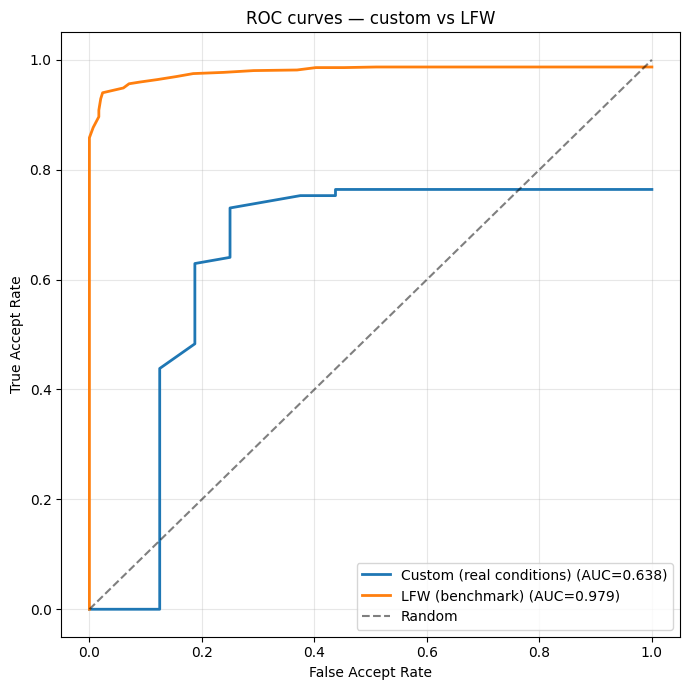

In [12]:
plt.figure(figsize=(7, 7))

for name, res in results.items():
    m = res["metrics"]
    # Walk thresholds high -> low so FAR increases monotonically (0 -> 1).
    # Sorting by far instead would fold the curve back on itself, very visible
    # with the tiny custom impostor set.
    order = np.argsort(THRESHOLDS)[::-1]
    far = m["far"][order]
    tar = m["tar"][order]
    plt.plot(far, tar, linewidth=2,label=f"{name} (AUC={m['auc']:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
plt.xlabel("False Accept Rate")
plt.ylabel("True Accept Rate")
plt.title("ROC curves — custom vs LFW")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Score distributions (the cause behind the ROC)

The ROC shows *the effect*; the score distributions show *the cause*. For each dataset we overlay the genuine and impostor score histograms. Well-separated histograms mean an easy classification problem; overlapping histograms mean a hard one. The **d'** value printed in each title summarises this separation in a single number.

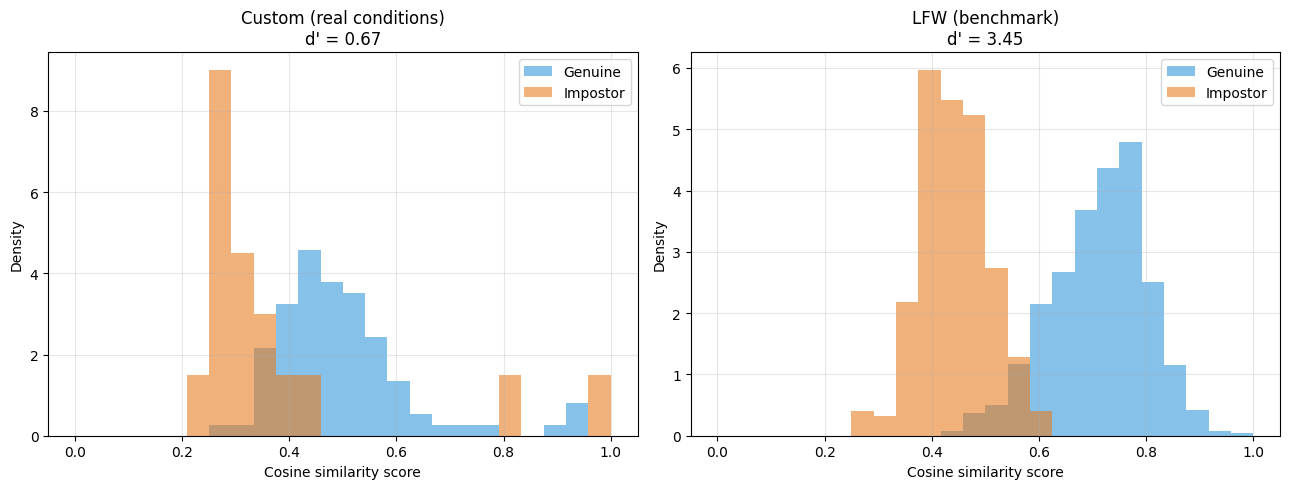

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, res) in zip(axes, results.items()):
    d = datasets[name]
    g = np.array([r["score"] for r in d["genuine"]])
    i = np.array([r["score"] for r in d["impostor"]])
    bins = np.linspace(0, 1, 25)
    ax.hist(g, bins=bins, alpha=0.6, label="Genuine",  color="#3498db", density=True)
    ax.hist(i, bins=bins, alpha=0.6, label="Impostor", color="#e67e22", density=True)
    ax.set_title(f"{name}\nd' = {res['dprime']:.2f}")
    ax.set_xlabel("Cosine similarity score")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Reading the comparison

In [14]:
c = results["Custom (real conditions)"]
l = results["LFW (benchmark)"]

display(Markdown(f"""
On **LFW**, the pipeline reaches an EER of **{l['metrics']['eer_value']*100:.1f}%**
(AUC **{l['metrics']['auc']:.3f}**, d' **{l['dprime']:.2f}**) with a tight confidence interval
([{l['eer_ci'][0]*100:.1f}%, {l['eer_ci'][1]*100:.1f}%]), thanks to the large sample
({l['n_genuine']} genuine / {l['n_impostor']} impostor). This is in line with a correctly
implemented ArcFace pipeline, and **validates that our code path: detection, alignment,
embedding, vector search, is sound**.

On our **custom dataset**, the EER rises to **{c['metrics']['eer_value']*100:.1f}%**
(AUC **{c['metrics']['auc']:.3f}**, d' **{c['dprime']:.2f}**), with a far wider interval
([{c['eer_ci'][0]*100:.1f}%, {c['eer_ci'][1]*100:.1f}%]) caused by the small, deliberately
difficult sample ({c['n_genuine']} genuine / {c['n_impostor']} impostor).

The gap is **not** evidence that the system is broken, LFW proves it is not. It quantifies
the cost of real-world acquisition conditions: webcam capture, occlusion, pose and lighting
variation, and a small enrolment base. The drop in d' (from {l['dprime']:.2f} to {c['dprime']:.2f})
is the clearest single summary: the embeddings are highly separable in ideal conditions and
barely separable in degraded ones. The honest conclusion for a proof-of-concept is that the
pipeline is correct in principle (LFW), and that robustness under degraded conditions (custom)
is the axis for future work, more enrolment images, data augmentation, and possibly a
discriminative classifier on the embeddings.
"""))


On **LFW**, the pipeline reaches an EER of **5.6%**
(AUC **0.979**, d' **3.45**) with a tight confidence interval
([3.7%, 7.0%]), thanks to the large sample
(917 genuine / 298 impostor). This is in line with a correctly
implemented ArcFace pipeline, and **validates that our code path: detection, alignment,
embedding, vector search, is sound**.

On our **custom dataset**, the EER rises to **26.0%**
(AUC **0.638**, d' **0.67**), with a far wider interval
([18.9%, 43.2%]) caused by the small, deliberately
difficult sample (89 genuine / 16 impostor).

The gap is **not** evidence that the system is broken, LFW proves it is not. It quantifies
the cost of real-world acquisition conditions: webcam capture, occlusion, pose and lighting
variation, and a small enrolment base. The drop in d' (from 3.45 to 0.67)
is the clearest single summary: the embeddings are highly separable in ideal conditions and
barely separable in degraded ones. The honest conclusion for a proof-of-concept is that the
pipeline is correct in principle (LFW), and that robustness under degraded conditions (custom)
is the axis for future work, more enrolment images, data augmentation, and possibly a
discriminative classifier on the embeddings.


## Limitations and future work

Three limitations frame how far these conclusions can be pushed. 

**(1) In-samplethreshold**: the operating threshold is derived from the EER point on the same data used for evaluation; a rigorous protocol would fix it on a separate validation split, so the reported figures carry a known optimistic bias. 

**(2) Impostor sample size on the custom set**: only 16 impostor attempts are successfully processed, so FAR moves in steps of ≈ 6%; the wide EER confidence interval [18.9%, 43.2%] and the degenerate TAR@FAR analysis both follow directly from this.

**(3) Dataset scale and composition**: the custom set was built
to oversample failure modes, so its aggregate metrics describe a stress scenario, not expected field performance.

Future work follows from the failure analysis rather than from the headline numbers: more enrolment images per identity (especially non-frontal), data augmentation for occlusion and pose, a larger impostor pool for the custom protocol, and possibly a discriminative classifier on top of the ArcFace embeddings to separate the confusable identity pairs identified in `evaluation.ipynb`.